# Bank Direct Marketing — LightGBM vs. SVM (Optuna-tuned)

Predicting term deposit subscription (`y`).


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

import lightgbm as lgb
from lightgbm import LGBMClassifier

import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================
DATA_PATH =  "/home/shawky/Documents/nti/actual nti/lightgbm/bank-direct-marketing-campaigns.csv"   # <-- UPDATE THIS PATH

try:
    df = pd.read_csv(DATA_PATH, sep=';')
    if df.shape[1] == 1:
        raise ValueError("Wrong delimiter")
except Exception:
    df = pd.read_csv(DATA_PATH, sep=',')

print(f"Loaded shape: {df.shape}")
df.head()


Loaded shape: (41188, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Row-level cleaning, then split

In [ ]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows ({(n_before - len(df)) / n_before * 100:.2f}%)")[]

if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("Dropped 'duration' (leakage feature).")

df['target'] = (df['y'] == 'yes').astype(int)
df = df.drop(columns=['y'])

categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['target']]
feature_cols = categorical_cols + numeric_cols

X = df[feature_cols]
y = df['target']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Positive rate — train: {y_train.mean():.4f} | val: {y_val.mean():.4f} | test: {y_test.mean():.4f}")


Dropped 1784 duplicate rows (4.33%)

Train: (27582, 19), Val: (5911, 19), Test: (5911, 19)
Positive rate — train: 0.1167 | val: 0.1167 | test: 0.1166


## 3. Preprocessing functions

In [4]:
def set_categorical_dtype(frame, cat_cols):
    frame = frame.copy()
    for col in cat_cols:
        frame[col] = frame[col].astype('category')
    return frame


def prep_for_lgbm(frame, cat_cols):
    return set_categorical_dtype(frame, cat_cols)


X_train_lgbm = prep_for_lgbm(X_train, categorical_cols)
X_val_lgbm = prep_for_lgbm(X_val, categorical_cols)
X_test_lgbm = prep_for_lgbm(X_test, categorical_cols)

## 4. LightGBM — Optuna tuning

Objective: maximize PR-AUC on the validation set (the right metric under this class
imbalance — accuracy/ROC-AUC alone would understate how hard the "yes" class is to find).
Each trial trains with early stopping against `X_val_lgbm`/`y_val`.

In [5]:
def lgbm_objective(trial):
    params = {
        'objective': 'binary',
        'is_unbalance': True,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_estimators': 2000,
        'random_state': RANDOM_STATE,
        'verbosity': -1,
    }

    model = LGBMClassifier(**params)
    model.fit(
        X_train_lgbm, y_train,
        eval_set=[(X_val_lgbm, y_val)],
        eval_metric='average_precision',
        categorical_feature=categorical_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    val_proba = model.predict_proba(X_val_lgbm)[:, 1]
    return average_precision_score(y_val, val_proba)


lgbm_study = optuna.create_study(direction='maximize', study_name='lgbm_tuning')
t0 = time.time()
lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=True)
lgbm_tuning_time = time.time() - t0

print(f"\nLightGBM tuning time: {lgbm_tuning_time:.1f}s over {len(lgbm_study.trials)} trials")
print(f"Best val PR-AUC: {lgbm_study.best_value:.4f}")
print(f"Best params: {lgbm_study.best_params}")


  0%|          | 0/30 [00:00<?, ?it/s]


LightGBM tuning time: 12.2s over 30 trials
Best val PR-AUC: 0.5001
Best params: {'learning_rate': 0.009307107864699472, 'num_leaves': 80, 'max_depth': 8, 'min_child_samples': 68, 'subsample': 0.9281635748747927, 'colsample_bytree': 0.6626464462412223, 'reg_alpha': 0.023365434575670842, 'reg_lambda': 0.016601636452501893}


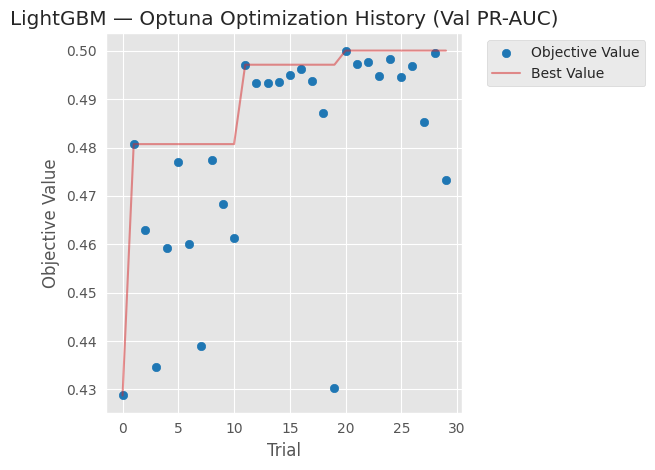

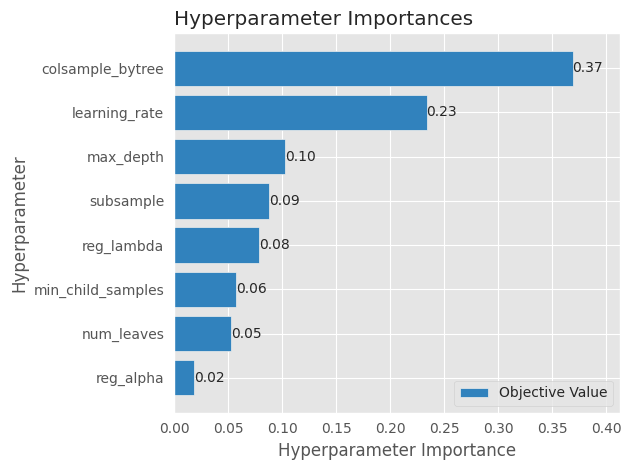

In [6]:
# Optuna diagnostic plots — LightGBM
fig1 = plot_optimization_history(lgbm_study)
plt.title("LightGBM — Optuna Optimization History (Val PR-AUC)")
plt.tight_layout()
plt.show()

fig2 = plot_param_importances(lgbm_study)
plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# Final LightGBM fit with best params
# ============================================================
best_lgbm_params = dict(lgbm_study.best_params)
best_lgbm_params.update({
    'objective': 'binary',
    'is_unbalance': True,
    'n_estimators': 2000,
    'random_state': RANDOM_STATE,
    'verbosity': -1,
})

lgbm = LGBMClassifier(**best_lgbm_params)

t0 = time.time()
lgbm.fit(
    X_train_lgbm, y_train,
    eval_set=[(X_val_lgbm, y_val)],
    eval_metric='average_precision',
    categorical_feature=categorical_cols,
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
)
lgbm_fit_time = time.time() - t0
print(f"\nFinal LightGBM fit time: {lgbm_fit_time:.1f}s | best iteration: {lgbm.best_iteration_}")


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[25]	valid_0's average_precision: 0.50005	valid_0's binary_logloss: 0.335732

Final LightGBM fit time: 0.7s | best iteration: 25


In [8]:
lgbm_proba = lgbm.predict_proba(X_test_lgbm)[:, 1]
lgbm_pred = (lgbm_proba >= 0.5).astype(int)

lgbm_roc_auc = roc_auc_score(y_test, lgbm_proba)
lgbm_pr_auc = average_precision_score(y_test, lgbm_proba)
lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred)

print(f"LightGBM (tuned)  |  ROC-AUC: {lgbm_roc_auc:.4f}  |  PR-AUC: {lgbm_pr_auc:.4f}  |  "
      f"Accuracy: {lgbm_acc:.4f}  |  F1 @0.5: {lgbm_f1:.4f}")


LightGBM (tuned)  |  ROC-AUC: 0.8030  |  PR-AUC: 0.4738  |  Accuracy: 0.8834  |  F1 @0.5: 0.0000


## 5. SVM — Optuna tuning

Tuning uses `decision_function` scores rather than `predict_proba` (i.e. `probability=False`
during search) — Platt scaling's internal CV makes `probability=True` far too slow to use
inside 15+ trials. `decision_function` still ranks examples correctly, so PR-AUC/ROC-AUC
computed from it are valid for comparing trials. The **final** model is refit once with
`probability=True` so it produces the same kind of output as LightGBM for the comparison
section.

Same subsampling caveat as before: SVM is tuned and trained on a **5,000-row subsample**
because kernel SVM doesn't scale to the full ~29k-row training set in reasonable time.

In [ ]:
# 1. Convert categorical columns to numeric codes across ALL splits
X_train_encoded = X_train_lgbm.copy()
X_val_encoded = X_val_lgbm.copy()
X_test_encoded = X_test_lgbm.copy()  # Added X_test_lgbm her

for col in categorical_cols:
  X_train_encoded[col] = X_train_encoded[col].cat.codes
  X_val_encoded[col] = X_val_encoded[col].cat.codes
  X_test_encoded[col] = X_test_encoded[col].cat.codes

SVM_SAMPLE_SIZE = 20000

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_encoded,
    y_train,
    train_size=SVM_SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_val_svm = X_val_encoded
X_test_svm = X_test_encoded 

In [20]:
def svm_objective(trial):
    C = trial.suggest_float('C', 1e-2, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e0, log=True)

    model = SVC(
        kernel='rbf', C=C, gamma=gamma,
        class_weight='balanced', probability=True,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_svm, y_train_svm)
    val_scores = model.decision_function(X_val_svm)
    return average_precision_score(y_val, val_scores)


svm_study = optuna.create_study(direction='maximize', study_name='svm_tuning')
t0 = time.time()
svm_study.optimize(svm_objective, n_trials=15, show_progress_bar=True)
svm_tuning_time = time.time() - t0

print(f"\nSVM tuning time: {svm_tuning_time:.1f}s over {len(svm_study.trials)} trials")
print(f"Best val PR-AUC: {svm_study.best_value:.4f}")
print(f"Best params: {svm_study.best_params}")


  0%|          | 0/15 [00:00<?, ?it/s]


SVM tuning time: 995.0s over 15 trials
Best val PR-AUC: 0.3768
Best params: {'C': 0.04100468043814929, 'gamma': 0.002281714612904955}


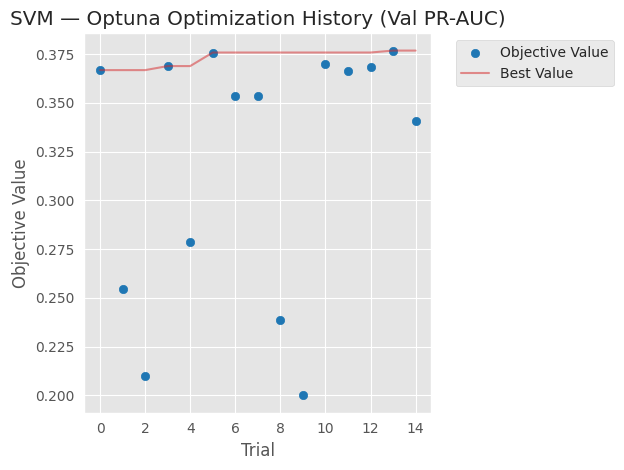

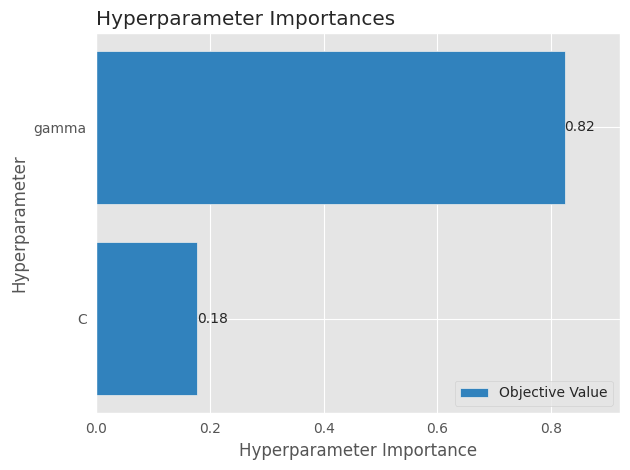

In [21]:
# Optuna diagnostic plots — SVM
fig3 = plot_optimization_history(svm_study)
plt.title("SVM — Optuna Optimization History (Val PR-AUC)")
plt.tight_layout()
plt.show()

fig4 = plot_param_importances(svm_study)
plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# Final SVM fit with best params (probability=True for comparable output)
# ============================================================
svm = SVC(
    kernel='rbf',
    C=svm_study.best_params['C'],
    gamma=svm_study.best_params['gamma'],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE,
)

t0 = time.time()
svm.fit(X_train_svm, y_train_svm)
svm_fit_time = time.time() - t0
print(f"Final SVM fit time: {svm_fit_time:.1f}s (includes Platt scaling CV)")


Final SVM fit time: 52.6s (includes Platt scaling CV)


In [23]:
svm_proba = svm.predict_proba(X_test_svm)[:, 1]
svm_pred = (svm_proba >= 0.5).astype(int)

svm_roc_auc = roc_auc_score(y_test, svm_proba)
svm_pr_auc = average_precision_score(y_test, svm_proba)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print(f"SVM (tuned)       |  ROC-AUC: {svm_roc_auc:.4f}  |  PR-AUC: {svm_pr_auc:.4f}  |  "
      f"Accuracy: {svm_acc:.4f}  |  F1 @0.5: {svm_f1:.4f}")


SVM (tuned)       |  ROC-AUC: 0.7788  |  PR-AUC: 0.3827  |  Accuracy: 0.8834  |  F1 @0.5: 0.0000


## 6. Head-to-head comparison

In [24]:
comparison = pd.DataFrame({
    'Model': ['LightGBM (tuned)', 'SVM (tuned)'],
    'Train rows used': [X_train_lgbm.shape[0], X_train_svm.shape[0]],
    'Optuna trials': [len(lgbm_study.trials), len(svm_study.trials)],
    'Tuning time (s)': [round(lgbm_tuning_time, 1), round(svm_tuning_time, 1)],
    'Final fit time (s)': [round(lgbm_fit_time, 1), round(svm_fit_time, 1)],
    'Accuracy': [lgbm_acc, svm_acc],
    'F1 @0.5': [lgbm_f1, svm_f1],
    'ROC-AUC': [lgbm_roc_auc, svm_roc_auc],
    'PR-AUC': [lgbm_pr_auc, svm_pr_auc],
})
comparison


,Model,Train rows used,Optuna trials,Tuning time (s),Final fit time (s),Accuracy,F1 @0.5,ROC-AUC,PR-AUC
0,LightGBM (tuned),27582,30,12.2,0.7,0.883438,0.0,0.802988,0.473754
1,SVM (tuned),20000,15,995.0,52.6,0.883438,0.0,0.778813,0.382719


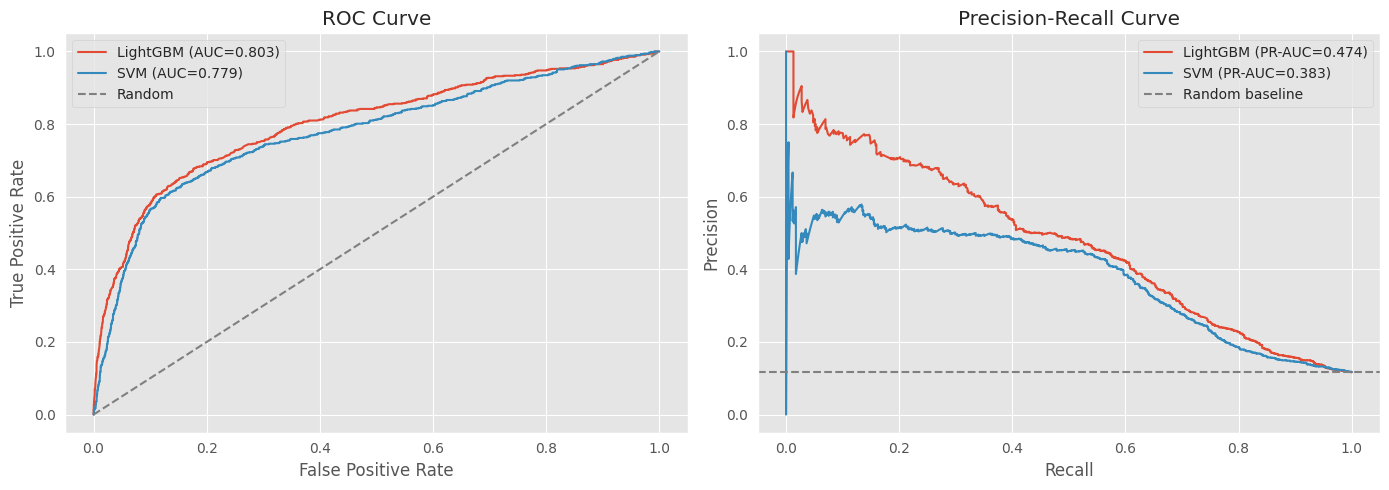

In [25]:
# ============================================================
# 6a. Score curves — ROC and Precision-Recall
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_l, tpr_l, _ = roc_curve(y_test, lgbm_proba)
fpr_s, tpr_s, _ = roc_curve(y_test, svm_proba)
axes[0].plot(fpr_l, tpr_l, label=f'LightGBM (AUC={lgbm_roc_auc:.3f})')
axes[0].plot(fpr_s, tpr_s, label=f'SVM (AUC={svm_roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

prec_l, rec_l, _ = precision_recall_curve(y_test, lgbm_proba)
prec_s, rec_s, _ = precision_recall_curve(y_test, svm_proba)
axes[1].plot(rec_l, prec_l, label=f'LightGBM (PR-AUC={lgbm_pr_auc:.3f})')
axes[1].plot(rec_s, prec_s, label=f'SVM (PR-AUC={svm_pr_auc:.3f})')
axes[1].axhline(y=y_test.mean(), linestyle='--', color='gray', label='Random baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.show()


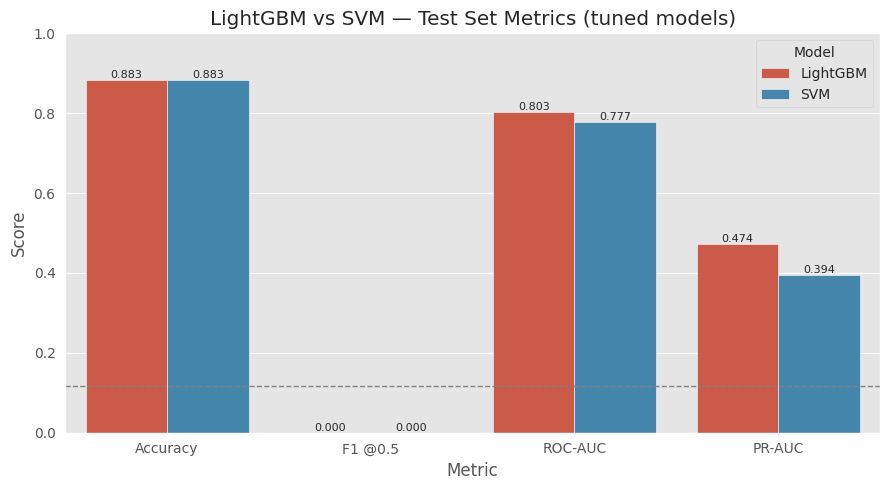

In [16]:
# ============================================================
# 6b. Accuracy & score bar chart
# ============================================================
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 @0.5', 'ROC-AUC', 'PR-AUC'] * 2,
    'Model': ['LightGBM'] * 4 + ['SVM'] * 4,
    'Score': [lgbm_acc, lgbm_f1, lgbm_roc_auc, lgbm_pr_auc,
              svm_acc, svm_f1, svm_roc_auc, svm_pr_auc],
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', ax=ax)
ax.axhline(y=y_test.mean(), linestyle='--', color='gray', linewidth=1, label='_nolegend_')
ax.set_ylim(0, 1)
ax.set_title('LightGBM vs SVM — Test Set Metrics (tuned models)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Threshold tuning & final report (LightGBM — the deployed model)

Best F1 threshold: 0.2385
  Precision: 0.4517 | Recall: 0.5631 | F1: 0.5013

--- Classification report @ tuned threshold 0.239 ---
              precision    recall  f1-score   support

          no       0.94      0.91      0.92      5222
         yes       0.45      0.56      0.50       689

    accuracy                           0.87      5911
   macro avg       0.70      0.74      0.71      5911
weighted avg       0.88      0.87      0.88      5911



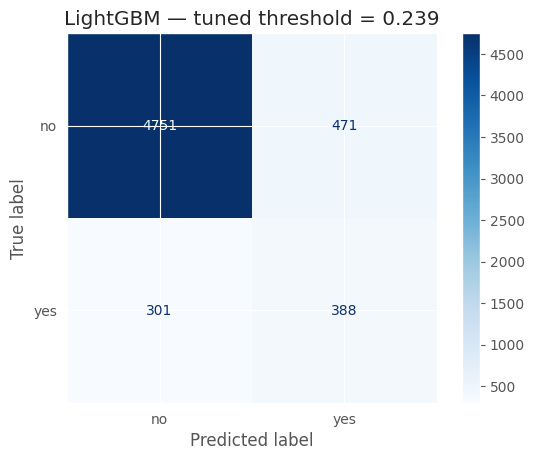

In [26]:
precisions, recalls, thresholds = precision_recall_curve(y_test, lgbm_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

y_pred_tuned = (lgbm_proba >= best_threshold).astype(int)
print(f"\n--- Classification report @ tuned threshold {best_threshold:.3f} ---")
print(classification_report(y_test, y_pred_tuned, target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, display_labels=['no', 'yes'], cmap='Blues')
plt.title(f"LightGBM — tuned threshold = {best_threshold:.3f}")
plt.show()


## 8. Feature importance (LightGBM)

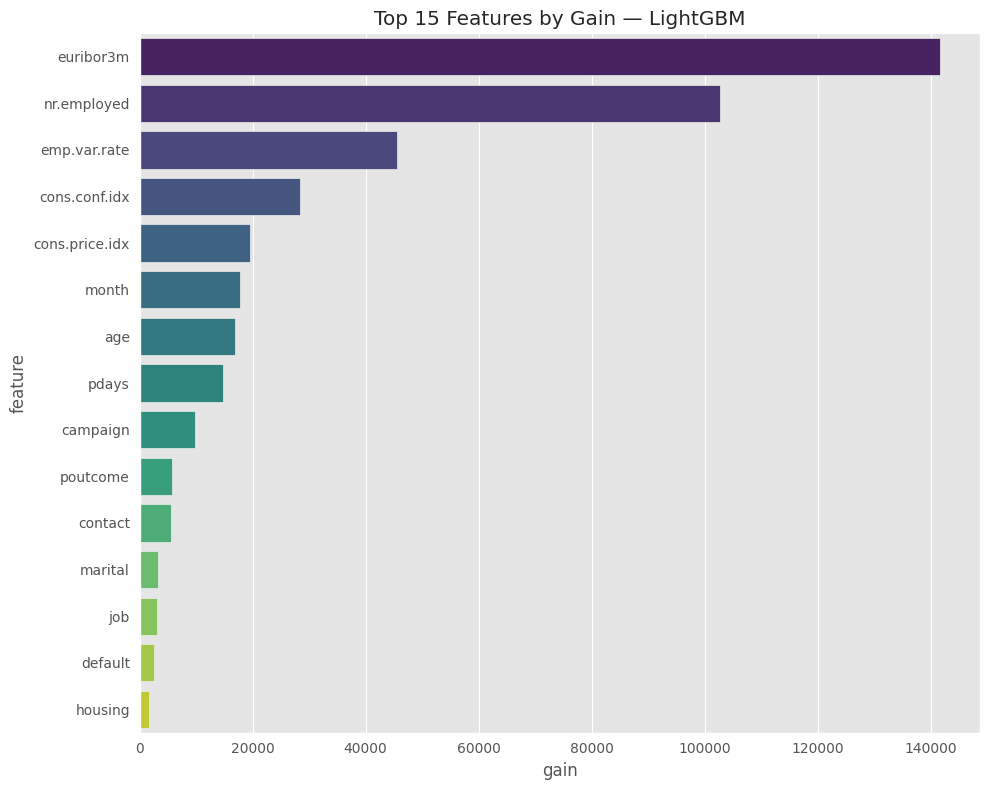

,feature,gain
17,euribor3m,141667.142931
18,nr.employed,102739.022795
14,emp.var.rate,45541.038880
16,cons.conf.idx,28434.820433
15,cons.price.idx,19612.400784
7,month,17762.902939
10,age,16859.656510
12,pdays,14742.852015
11,campaign,9741.821983
9,poutcome,5734.054117


In [27]:
importance_df = pd.DataFrame({
    'feature': lgbm.booster_.feature_name(),
    'gain': lgbm.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), y='feature', x='gain', ax=ax, palette='viridis')
ax.set_title('Top 15 Features by Gain — LightGBM')
plt.tight_layout()
plt.show()

importance_df.head(15)


## Notes

- **Metric for tuning**: PR-AUC on a held-out validation set, not accuracy or ROC-AUC — with an 88.7/11.3 class split, accuracy is dominated by the majority class and would happily reward a model that barely finds any "yes" cases.
- **`n_trials`**: 30 for LightGBM, 15 for SVM — SVM trials are much slower per-trial (even without Platt scaling) so fewer are used to keep runtime sane. Raise both if you have time budget.
- **Why `probability=False` during SVM tuning**: `probability=True` runs an internal 5-fold CV every single fit just to calibrate probabilities — doing that inside an Optuna loop multiplies runtime badly for no ranking-quality benefit, since PR-AUC/ROC-AUC only need a valid ranking score, which `decision_function` already provides.
- **Optuna plots**: `plot_optimization_history` shows whether the search converged (best-value line flattening) or would likely still improve with more trials; `plot_param_importances` tells you which hyperparameters actually mattered — usually `learning_rate`/`num_leaves` for LightGBM and `C`/`gamma` for SVM dominate.
